In [6]:
import pandas as pd

df = pd.read_csv('student-scores.csv')

df.head()

,id,first_name,last_name,email,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
0,1,Paul,Casey,paul.casey.1@gslingacademy.com,male,False,3,False,27,Lawyer,73,81,93,97,63,80,87
1,2,Danielle,Sandoval,danielle.sandoval.2@gslingacademy.com,female,False,2,False,47,Doctor,90,86,96,100,90,88,90
2,3,Tina,Andrews,tina.andrews.3@gslingacademy.com,female,False,9,True,13,Government Officer,81,97,95,96,65,77,94
3,4,Tara,Clark,tara.clark.4@gslingacademy.com,female,False,5,False,3,Artist,71,74,88,80,89,63,86
4,5,Anthony,Campos,anthony.campos.5@gslingacademy.com,male,False,5,False,10,Unknown,84,77,65,65,80,74,76


In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv('student-scores.csv')

print("format:", df.shape)
df.head()


format: (2000, 17)


,id,first_name,last_name,email,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
0,1,Paul,Casey,paul.casey.1@gslingacademy.com,male,False,3,False,27,Lawyer,73,81,93,97,63,80,87
1,2,Danielle,Sandoval,danielle.sandoval.2@gslingacademy.com,female,False,2,False,47,Doctor,90,86,96,100,90,88,90
2,3,Tina,Andrews,tina.andrews.3@gslingacademy.com,female,False,9,True,13,Government Officer,81,97,95,96,65,77,94
3,4,Tara,Clark,tara.clark.4@gslingacademy.com,female,False,5,False,3,Artist,71,74,88,80,89,63,86
4,5,Anthony,Campos,anthony.campos.5@gslingacademy.com,male,False,5,False,10,Unknown,84,77,65,65,80,74,76


In [8]:
print("missing values\n", df.isnull().sum()) #check for missing values

df_encoded = pd.get_dummies(df, drop_first=True) #converting string values to numbers using One-Hot

print("new shape after encoding:", df_encoded.shape)

missing values
 id                            0
first_name                    0
last_name                     0
email                         0
gender                        0
part_time_job                 0
absence_days                  0
extracurricular_activities    0
weekly_self_study_hours       0
career_aspiration             0
math_score                    0
history_score                 0
physics_score                 0
chemistry_score               0
biology_score                 0
english_score                 0
geography_score               0
dtype: int64
new shape after encoding: (2000, 3186)


In [9]:
df_encoded.head()

,id,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,math_score,history_score,physics_score,chemistry_score,biology_score,...,career_aspiration_Game Developer,career_aspiration_Government Officer,career_aspiration_Lawyer,career_aspiration_Real Estate Developer,career_aspiration_Scientist,career_aspiration_Software Engineer,career_aspiration_Stock Investor,career_aspiration_Teacher,career_aspiration_Unknown,career_aspiration_Writer
0,1,False,3,False,27,73,81,93,97,63,...,False,False,True,False,False,False,False,False,False,False
1,2,False,2,False,47,90,86,96,100,90,...,False,False,False,False,False,False,False,False,False,False
2,3,False,9,True,13,81,97,95,96,65,...,False,True,False,False,False,False,False,False,False,False
3,4,False,5,False,3,71,74,88,80,89,...,False,False,False,False,False,False,False,False,False,False
4,5,False,5,False,10,84,77,65,65,80,...,False,False,False,False,False,False,False,False,True,False


In [10]:
# Calculate the correlation of all features with math_score
correlations = df_encoded.corr()['math_score'].sort_values(ascending=False)

print("Correlation with Math Score:")
print(correlations)

Correlation with Math Score:
math_score                                 1.000000
weekly_self_study_hours                    0.393569
career_aspiration_Software Engineer        0.284310
career_aspiration_Doctor                   0.163094
history_score                              0.147247
                                             ...   
career_aspiration_Unknown                 -0.096695
career_aspiration_Real Estate Developer   -0.110642
part_time_job                             -0.185573
absence_days                              -0.237072
career_aspiration_Business Owner          -0.446430
Name: math_score, Length: 3186, dtype: float64


In [11]:
# Calculate correlation of all subjects against Math
sub_features = ['physics_score', 'chemistry_score', 'biology_score', 'math_score', 'history_score', 'english_score', 'geography_score']

# This creates a small table showing the relationship between subjects
correlation_matrix = df[sub_features].corr()

print("Correlation of all subjects with Math Score:")
print(correlation_matrix['math_score'].sort_values(ascending=False))

Correlation of all subjects with Math Score:
math_score         1.000000
history_score      0.147247
english_score      0.134831
chemistry_score    0.127131
physics_score      0.115719
biology_score      0.081298
geography_score    0.049672
Name: math_score, dtype: float64


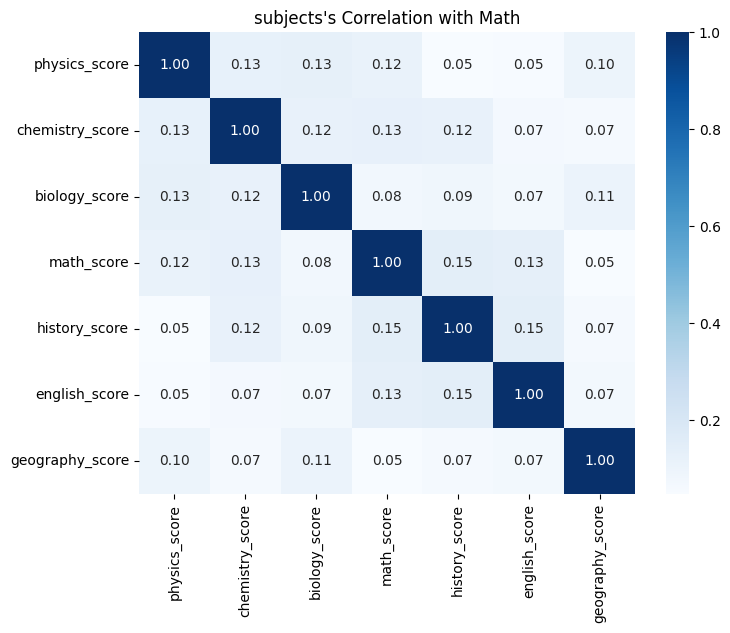

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt='.2f')
plt.title("subjects's Correlation with Math")
plt.show()

In [13]:
y = df_encoded['math_score'] #I have A variant with math scores  
features = ['weekly_self_study_hours', 'history_score', 'chemistry_score', 'english_score'] 
X = df_encoded[features]  

print("features selected for training:") 
print(X)

features selected for training:
      weekly_self_study_hours  history_score  chemistry_score  english_score
0                          27             81               97             80
1                          47             86              100             88
2                          13             97               96             77
3                           3             74               80             63
4                          10             77               65             74
...                       ...            ...              ...            ...
1995                       30             77               73             84
1996                       20             65               80             67
1997                       14             85               93             94
1998                        5             96               89             88
1999                       27             99               69             93

[2000 rows x 4 columns]


In [14]:
from sklearn.model_selection import train_test_split

# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 1600
Test set size: 400


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Model 1: Linear Regression
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# Model 2: Random Forest Regressor
model_rf = RandomForestRegressor(n_estimators=100, random_state=42) #Bagging (Bootstrap Aggregating)
model_rf.fit(X_train, y_train)

print("Models have been trained successfully.")

Models have been trained successfully.


In [16]:
# Generate predictions for both models
y_pred_lr = model_lr.predict(X_test)
y_pred_rf = model_rf.predict(X_test)

# Create a small DataFrame to compare actual vs predicted values
comparison_df = pd.DataFrame({
    'Actual_Math_Score': y_test.values,
    'LR_Predicted': y_pred_lr,
    'RF_Predicted': y_pred_rf
})

print("Comparison of Actual vs Predicted (first 5 rows):")
print(comparison_df.head())

Comparison of Actual vs Predicted (first 5 rows):
   Actual_Math_Score  LR_Predicted  RF_Predicted
0                 97     85.177311         90.48
1                 85     76.533519         73.42
2                 80     82.394877         86.17
3                 57     78.012364         71.68
4                 86     76.772021         80.89


In [17]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

def get_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"{model_name} Performance")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"R-squared Score (R2): {r2:.2f}\n")

# Run evaluation
get_metrics(y_test, y_pred_lr, "Linear Regression")
get_metrics(y_test, y_pred_rf, "Random Forest")

Linear Regression Performance
Mean Absolute Error (MAE): 9.45
Root Mean Squared Error (RMSE): 11.72
R-squared Score (R2): 0.17

Random Forest Performance
Mean Absolute Error (MAE): 10.23
Root Mean Squared Error (RMSE): 12.81
R-squared Score (R2): 0.01



In [18]:
In this assignment, we built regression models to predict math scores. 
We prepared the dataset, selected relevant features, and trained Linear Regression and Random Forest models. 
The Random Forest model performed better based on RMSE, MAE, and R² metrics. 
This shows that more complex models can better capture patterns in the data. 
Overall, this task helped us understand regression and model evaluation.

SyntaxError: invalid character '²' (U+00B2) (1277489570.py, line 3)